# E2.2 – Product & Transaction Embeddings

This is the **second FMFD** in the *Decoding Risk* project.

When a loan application arrives, the risk system needs to understand not just the customer but
also the *product being requested*.  Here we encode every financial product and incoming
transaction as a dense vector, using the same approach as Notebook 1.

**What we do here:**
1. Generate a catalogue of 10 standard bank products (mortgage, personal loan, etc.)
2. Generate 500 synthetic loan transactions (a customer asking for a specific product)
3. Convert both to natural-language descriptions and embed them
4. Persist the embeddings for use in Notebook 3
5. Visualise the product embedding space
6. Demonstrate product-similarity search

> **Prerequisites:** Run Notebook 1 first to install the dependencies.

---
**Author:** Adebanji Oluwatimileyin Adelowo  
**GitHub:** [adebanjiadelowo](https://github.com/adebanjiadelowo)

In [1]:
import numpy as np
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap

random.seed(42)
np.random.seed(42)

## 1 – Product catalogue

A bank typically offers a fixed set of product types.  We define ten products with realistic
parameters (amounts, terms, rates, collateral requirements).

In [2]:
PRODUCTS = [
    {'product_id': 'PROD_001', 'type': 'Personal Loan',     'min_amount': 1_000,    'max_amount': 50_000,   'min_term': 12,  'max_term': 84,  'base_rate': 8.5,  'collateral': False, 'risk_level': 'Medium'},
    {'product_id': 'PROD_002', 'type': 'Mortgage',          'min_amount': 50_000,   'max_amount': 800_000,  'min_term': 120, 'max_term': 360, 'base_rate': 4.2,  'collateral': True,  'risk_level': 'Low'},
    {'product_id': 'PROD_003', 'type': 'Car Loan',          'min_amount': 5_000,    'max_amount': 80_000,   'min_term': 24,  'max_term': 84,  'base_rate': 6.9,  'collateral': True,  'risk_level': 'Low'},
    {'product_id': 'PROD_004', 'type': 'Business Loan',     'min_amount': 10_000,   'max_amount': 500_000,  'min_term': 12,  'max_term': 120, 'base_rate': 7.5,  'collateral': True,  'risk_level': 'High'},
    {'product_id': 'PROD_005', 'type': 'Credit Card',       'min_amount': 500,      'max_amount': 30_000,   'min_term': 1,   'max_term': 1,   'base_rate': 19.9, 'collateral': False, 'risk_level': 'Medium'},
    {'product_id': 'PROD_006', 'type': 'Student Loan',      'min_amount': 1_000,    'max_amount': 60_000,   'min_term': 60,  'max_term': 120, 'base_rate': 5.5,  'collateral': False, 'risk_level': 'Medium'},
    {'product_id': 'PROD_007', 'type': 'Home Equity Loan',  'min_amount': 10_000,   'max_amount': 250_000,  'min_term': 60,  'max_term': 180, 'base_rate': 5.8,  'collateral': True,  'risk_level': 'Low'},
    {'product_id': 'PROD_008', 'type': 'Payday Loan',       'min_amount': 100,      'max_amount': 2_000,    'min_term': 1,   'max_term': 3,   'base_rate': 36.0, 'collateral': False, 'risk_level': 'Very High'},
    {'product_id': 'PROD_009', 'type': 'Overdraft',         'min_amount': 100,      'max_amount': 10_000,   'min_term': 1,   'max_term': 12,  'base_rate': 15.0, 'collateral': False, 'risk_level': 'Medium'},
    {'product_id': 'PROD_010', 'type': 'Investment Loan',   'min_amount': 5_000,    'max_amount': 200_000,  'min_term': 12,  'max_term': 60,  'base_rate': 9.0,  'collateral': True,  'risk_level': 'High'},
]

products_df = pd.DataFrame(PRODUCTS)
print('Product catalogue ({} products):'.format(len(products_df)))
products_df

Product catalogue (10 products):


,product_id,type,min_amount,max_amount,min_term,max_term,base_rate,collateral,risk_level
0,PROD_001,Personal Loan,1000,50000,12,84,8.5,False,Medium
1,PROD_002,Mortgage,50000,800000,120,360,4.2,True,Low
2,PROD_003,Car Loan,5000,80000,24,84,6.9,True,Low
3,PROD_004,Business Loan,10000,500000,12,120,7.5,True,High
4,PROD_005,Credit Card,500,30000,1,1,19.9,False,Medium
5,PROD_006,Student Loan,1000,60000,60,120,5.5,False,Medium
6,PROD_007,Home Equity Loan,10000,250000,60,180,5.8,True,Low
7,PROD_008,Payday Loan,100,2000,1,3,36.0,False,Very High
8,PROD_009,Overdraft,100,10000,1,12,15.0,False,Medium
9,PROD_010,Investment Loan,5000,200000,12,60,9.0,True,High


## 2 – Synthetic loan transactions

Each transaction represents a customer requesting a specific product at a particular amount and
term.  The transaction embedding is what gets concatenated with the client embedding in Notebook 3.

In [3]:
def generate_transactions(n=500):
    rows = []
    for i in range(n):
        prod = random.choice(PRODUCTS)
        amount = random.randint(prod['min_amount'], prod['max_amount'])
        term   = random.randint(prod['min_term'],   prod['max_term'])
        # Adjust rate slightly per transaction
        rate   = round(prod['base_rate'] + random.uniform(-1.0, 2.0), 2)
        rows.append({
            'transaction_id': 'TXN_{:04d}'.format(i),
            'customer_id':    'CUST_{:04d}'.format(random.randint(0, 499)),
            'product_id':     prod['product_id'],
            'product_type':   prod['type'],
            'amount':         amount,
            'term_months':    term,
            'interest_rate':  rate,
            'collateral':     prod['collateral'],
            'risk_level':     prod['risk_level'],
        })
    return pd.DataFrame(rows)


txn_df = generate_transactions(500)
print('Transactions dataset shape:', txn_df.shape)
txn_df.head()

Transactions dataset shape: (500, 9)


,transaction_id,customer_id,product_id,product_type,amount,term_months,interest_rate,collateral,risk_level
0,TXN_0000,CUST_0114,PROD_002,Mortgage,76225,309,4.03,True,Low
1,TXN_0001,CUST_0279,PROD_003,Car Loan,18434,67,8.12,True,Low
2,TXN_0002,CUST_0047,PROD_002,Mortgage,669176,228,3.30,True,Low
3,TXN_0003,CUST_0287,PROD_004,Business Loan,131981,76,8.31,True,High
4,TXN_0004,CUST_0214,PROD_004,Business Loan,385400,95,8.60,True,High


## 3 – Convert to natural language

In [4]:
def product_to_text(row):
    collateral_note = 'Collateral required.' if row['collateral'] else 'No collateral required.'
    parts = [
        'Product type: {}.'.format(row['product_type']),
        'Loan amount requested: ${:,}.'.format(int(row['amount'])),
        'Repayment term: {} months.'.format(int(row['term_months'])),
        'Interest rate: {:.2f}%.'.format(float(row['interest_rate'])),
        collateral_note,
        'Inherent risk level of product: {}.'.format(row['risk_level']),
        'Monthly instalment estimate: ${:,.0f}.'.format(
            float(row['amount']) * float(row['interest_rate']) / 100 / 12
            + float(row['amount']) / max(int(row['term_months']), 1)
        ),
    ]
    return ' '.join(parts)


def product_catalogue_to_text(row):
    collateral_note = 'Requires collateral.' if row['collateral'] else 'Unsecured product.'
    parts = [
        'Bank product: {}.'.format(row['type']),
        'Available amounts: ${:,} to ${:,}.'.format(int(row['min_amount']), int(row['max_amount'])),
        'Terms available: {} to {} months.'.format(int(row['min_term']), int(row['max_term'])),
        'Base interest rate: {:.1f}%.'.format(float(row['base_rate'])),
        collateral_note,
        'Risk category: {}.'.format(row['risk_level']),
    ]
    return ' '.join(parts)


txn_df['text']     = txn_df.apply(product_to_text, axis=1)
products_df['text'] = products_df.apply(product_catalogue_to_text, axis=1)

print('Sample transaction text:')
print(txn_df['text'].iloc[0])
print()
print('Sample product catalogue text:')
print(products_df['text'].iloc[0])

Sample transaction text:
Product type: Mortgage. Loan amount requested: $76,225. Repayment term: 309 months. Interest rate: 4.03%. Collateral required. Inherent risk level of product: Low. Monthly instalment estimate: $503.

Sample product catalogue text:
Bank product: Personal Loan. Available amounts: $1,000 to $50,000. Terms available: 12 to 84 months. Base interest rate: 8.5%. Unsecured product. Risk category: Medium.


## 4 – Generate embeddings

In [5]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print('Encoding transaction descriptions ...')
txn_embeddings = model.encode(
    txn_df['text'].tolist(),
    show_progress_bar=True,
    batch_size=64,
)

print('Encoding product catalogue ...')
product_embeddings = model.encode(
    products_df['text'].tolist(),
    show_progress_bar=True,
)

print('\nTransaction embeddings shape:', txn_embeddings.shape)
print('Product catalogue embeddings shape:', product_embeddings.shape)

W0502 19:05:32.033000 86282 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding transaction descriptions ...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Encoding product catalogue ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Transaction embeddings shape: (500, 384)
Product catalogue embeddings shape: (10, 384)


## 5 – Persist

In [6]:
txn_payload = {
    'embeddings':       txn_embeddings,
    'transaction_ids':  txn_df['transaction_id'].tolist(),
    'metadata':         txn_df.drop(columns=['text']).to_dict('records'),
}
with open('transaction_embeddings.pkl', 'wb') as f:
    pickle.dump(txn_payload, f)

prod_payload = {
    'embeddings':   product_embeddings,
    'product_ids':  products_df['product_id'].tolist(),
    'metadata':     products_df.drop(columns=['text']).to_dict('records'),
}
with open('product_catalogue_embeddings.pkl', 'wb') as f:
    pickle.dump(prod_payload, f)

print('Saved transaction_embeddings.pkl ({} records)'.format(len(txn_payload['transaction_ids'])))
print('Saved product_catalogue_embeddings.pkl ({} products)'.format(len(prod_payload['product_ids'])))

Saved transaction_embeddings.pkl (500 records)
Saved product_catalogue_embeddings.pkl (10 products)


## 6 – Visualise product catalogue in 2D

With only 10 products we can label every point directly.

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


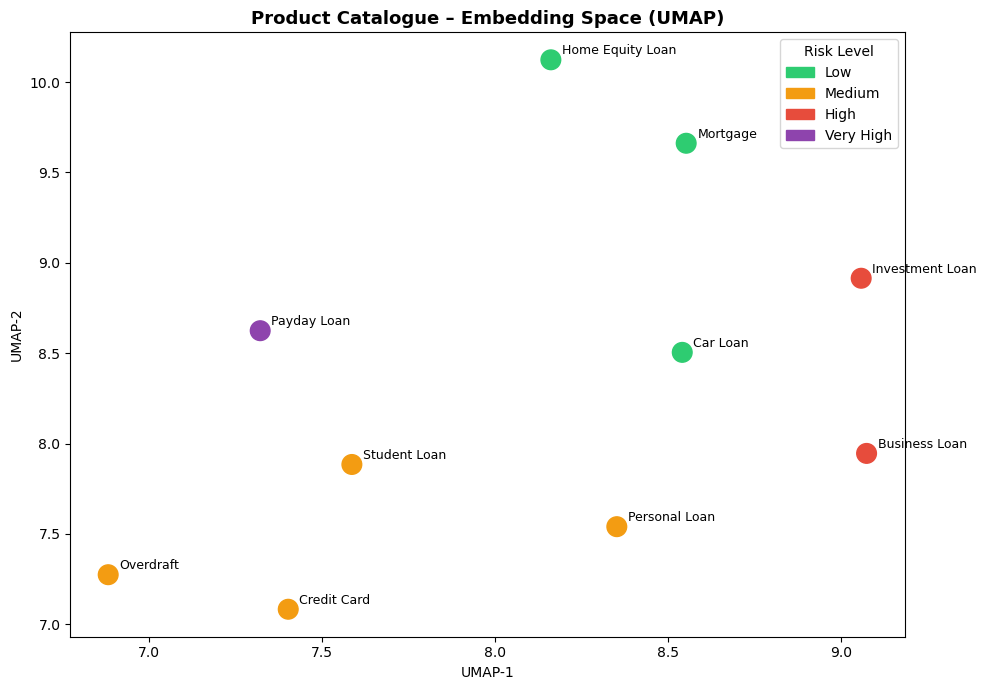

In [7]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=4)
cat_coords = reducer.fit_transform(product_embeddings)

risk_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c', 'Very High': '#8e44ad'}
colors = [risk_colors[r] for r in products_df['risk_level']]

plt.figure(figsize=(10, 7))
plt.scatter(cat_coords[:, 0], cat_coords[:, 1], c=colors, s=200, zorder=3)

for i, row in products_df.iterrows():
    plt.annotate(
        row['type'],
        (cat_coords[i, 0], cat_coords[i, 1]),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=9,
    )

from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in risk_colors.items()]
plt.legend(handles=legend, title='Risk Level', loc='best')
plt.title('Product Catalogue – Embedding Space (UMAP)', fontsize=13, fontweight='bold')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.tight_layout()
plt.savefig('product_embeddings_umap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 – Transaction embedding space

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


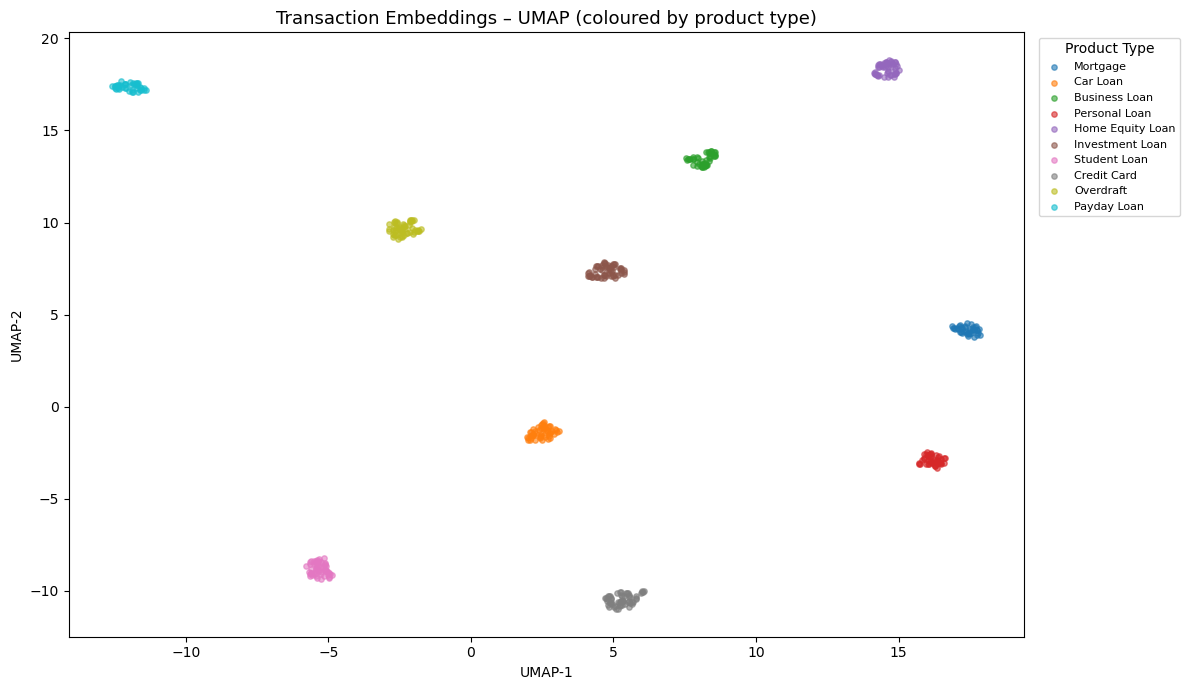

In [8]:
txn_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
txn_coords  = txn_reducer.fit_transform(txn_embeddings)

product_types = txn_df['product_type'].unique()
cmap = plt.get_cmap('tab10')
color_map = {pt: cmap(i) for i, pt in enumerate(product_types)}
txn_colors = [color_map[pt] for pt in txn_df['product_type']]

plt.figure(figsize=(12, 7))
for pt in product_types:
    mask = txn_df['product_type'] == pt
    plt.scatter(
        txn_coords[mask, 0], txn_coords[mask, 1],
        c=[color_map[pt]], label=pt, alpha=0.6, s=15
    )

plt.legend(title='Product Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.title('Transaction Embeddings – UMAP (coloured by product type)', fontsize=13)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.tight_layout()
plt.savefig('transaction_embeddings_umap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 – Product similarity search

Given a transaction embedding, find the most similar products in the catalogue.  This could
power a recommendation engine alongside the risk decision.

In [9]:
def find_similar_products(txn_idx, txn_embs, prod_embs, txn_df, prod_df, top_k=3):
    query = txn_embs[txn_idx].reshape(1, -1)
    sims  = cosine_similarity(query, prod_embs)[0]
    top_idx = np.argsort(sims)[-top_k:][::-1]

    t = txn_df.iloc[txn_idx]
    print('=== Transaction {} ==='.format(t['transaction_id']))
    print('Product: {}  |  Amount: ${:,}  |  Term: {} mo  |  Rate: {:.2f}%'.format(
        t['product_type'], int(t['amount']), int(t['term_months']), float(t['interest_rate'])))

    print('\nTop {} similar catalogue products:'.format(top_k))
    print('-' * 70)
    for rank, idx in enumerate(top_idx, 1):
        p = prod_df.iloc[idx]
        print('{}. {} (risk: {})  |  Rate: {:.1f}%  |  Similarity: {:.4f}'.format(
            rank, p['type'], p['risk_level'], float(p['base_rate']), sims[idx]))


for qi in [0, 10, 50]:
    find_similar_products(qi, txn_embeddings, product_embeddings, txn_df, products_df)
    print()

=== Transaction TXN_0000 ===
Product: Mortgage  |  Amount: $76,225  |  Term: 309 mo  |  Rate: 4.03%

Top 3 similar catalogue products:
----------------------------------------------------------------------
1. Mortgage (risk: Low)  |  Rate: 4.2%  |  Similarity: 0.8585
2. Personal Loan (risk: Medium)  |  Rate: 8.5%  |  Similarity: 0.7731
3. Investment Loan (risk: High)  |  Rate: 9.0%  |  Similarity: 0.7465

=== Transaction TXN_0010 ===
Product: Home Equity Loan  |  Amount: $30,656  |  Term: 130 mo  |  Rate: 5.68%

Top 3 similar catalogue products:
----------------------------------------------------------------------
1. Home Equity Loan (risk: Low)  |  Rate: 5.8%  |  Similarity: 0.8832
2. Personal Loan (risk: Medium)  |  Rate: 8.5%  |  Similarity: 0.7011
3. Mortgage (risk: Low)  |  Rate: 4.2%  |  Similarity: 0.6979

=== Transaction TXN_0050 ===
Product: Student Loan  |  Amount: $28,759  |  Term: 86 mo  |  Rate: 5.90%

Top 3 similar catalogue products:
------------------------------------

## Summary

We now have:
- **`transaction_embeddings.pkl`** – 500 transaction vectors
- **`product_catalogue_embeddings.pkl`** – 10 product catalogue vectors

**Next step →** [E2_3_Risk_Decision_Model.ipynb](E2_3_Risk_Decision_Model.ipynb) concatenates
client and transaction embeddings and trains a multi-output risk classifier.